<a href="https://colab.research.google.com/github/vivekjain060305-coder/Wine_Quality_Prerdiction/blob/main/WQP_Decission_tree_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving wine-quality-white-and-red.csv to wine-quality-white-and-red (1).csv
Accuracy: 84.92307692307692
Precision Score: 0.6153846153846154
F1 Score: 0.608
AUC Score: 0.7550275396295081


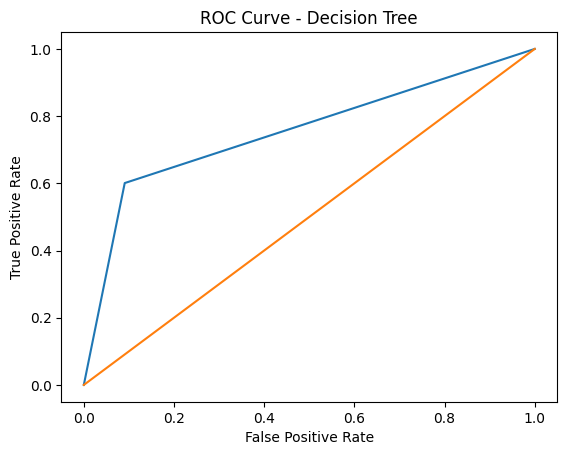

In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score


# Step 2: Upload dataset
from google.colab import files
uploaded = files.upload()

# Step 3: Load dataset
df = pd.read_csv("wine-quality-white-and-red.csv")

# Step 4: Create binary classification label
df["quality_label"] = (df["quality"] >= 7).astype(int)

# Step 5: Define features and target
X = df.drop(["quality","quality_label"], axis=1)
y = df["quality_label"]

# Identify categorical and numerical features
categorical_features = ['type']
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# Create preprocessing pipelines for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 7: Apply preprocessing and scaling
# Create a pipeline that first preprocesses the data and then trains the model
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', DecisionTreeClassifier(random_state=42))])

# Train the model using the pipeline
model_pipeline.fit(X_train, y_train)

# Step 8: Predictions
y_pred = model_pipeline.predict(X_test)
y_pred_prob = model_pipeline.predict_proba(X_test)[:,1]

# Step 9: Metrics (renumbered due to pipeline inclusion)
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision Score:", precision)
print("F1 Score:", f1)

# Step 10: ROC and AUC (renumbered)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

print("AUC Score:", auc_score)

# Step 11: ROC Curve (renumbered)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.show()